In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

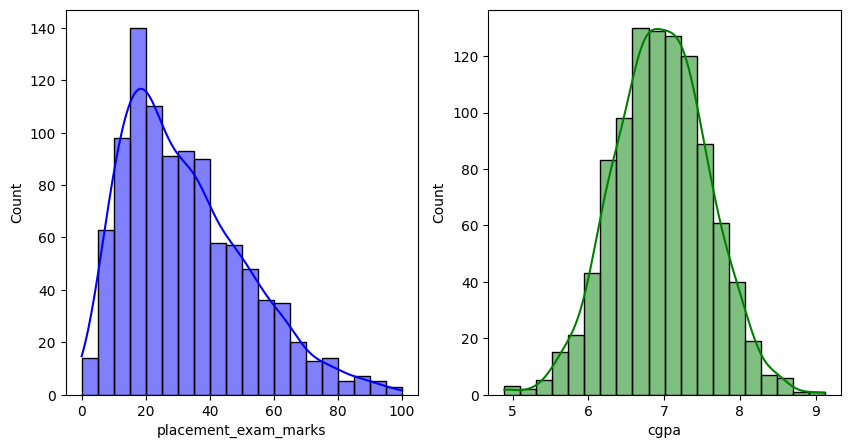

In [11]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['placement_exam_marks'], bins=20, color='blue', edgecolor='black', kde=True)
plt.subplot(1,2,2)
sns.histplot(df['cgpa'], bins=20, color='green', edgecolor='black', kde=True)

plt.show()

In [12]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

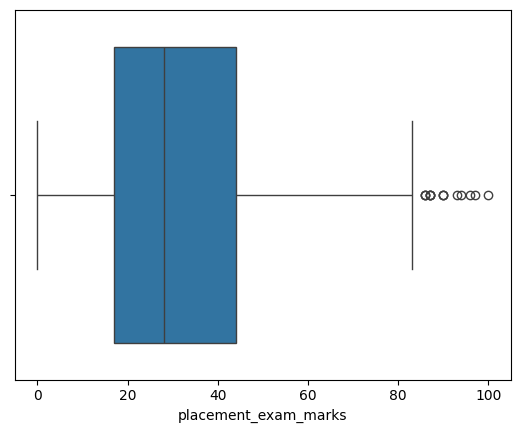

In [13]:
sns.boxplot(x=df['placement_exam_marks'])

In [14]:
# Finding the IQR (Interquartile Range)
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)

In [15]:
Q1

np.float64(17.0)

In [16]:
Q3

np.float64(44.0)

In [18]:
IQR = Q3 - Q1
IQR

np.float64(27.0)

In [19]:
# Lower and Upper Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -23.5
Upper Bound: 84.5


### Finding Outliers

In [20]:
df[df['placement_exam_marks'] > upper_bound]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [21]:
df[df['placement_exam_marks'] < lower_bound]

,cgpa,placement_exam_marks,placed


### Trimming

In [22]:
new_df=df[(df['placement_exam_marks'] >= lower_bound) & (df['placement_exam_marks'] <= upper_bound)]

In [23]:
new_df.shape

(985, 3)

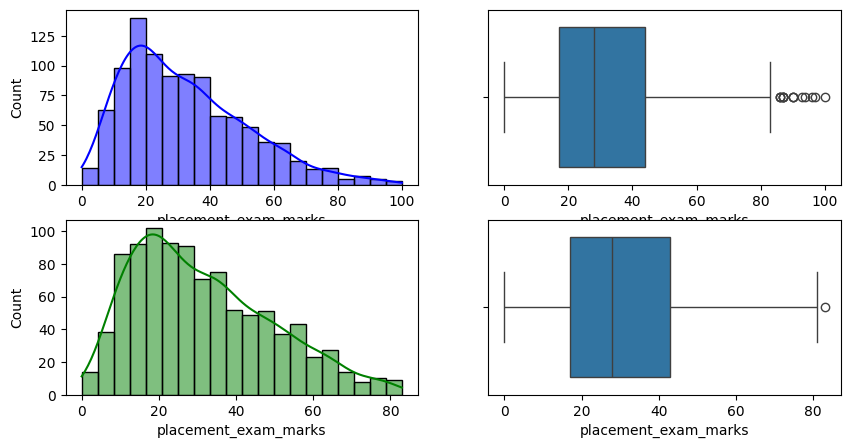

In [27]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], bins=20, color='blue', edgecolor='black', kde=True)
plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], bins=20, color='green', edgecolor='black', kde=True)
plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.show()

### Capping

In [29]:
new_df_cap=df.copy()
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks']>upper_bound,
    upper_bound,
    np.where(
        new_df_cap['placement_exam_marks']<lower_bound,
        lower_bound,
        new_df_cap['placement_exam_marks']
    )
)

In [31]:
new_df_cap.shape

(1000, 3)

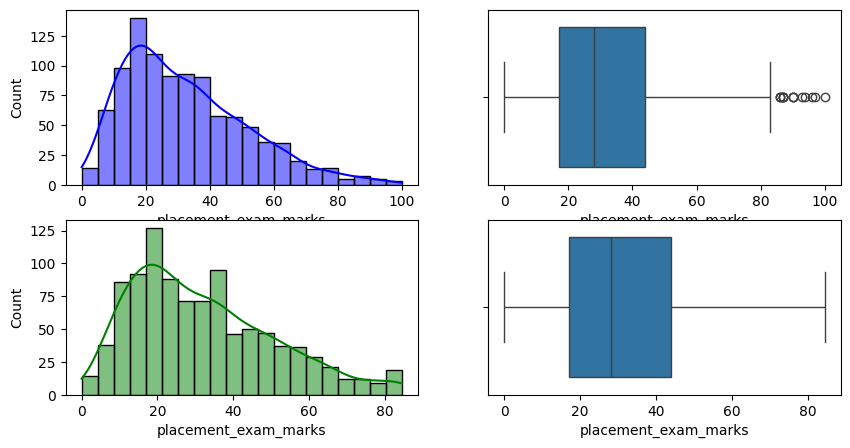

In [36]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],bins=20,color='blue',edgecolor='black',kde=True)
plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_df_cap["placement_exam_marks"],bins=20,color='green',edgecolor='black',kde=True)
plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.show()